<a href="https://colab.research.google.com/github/braltoids0089/EQUITY-RESEARCH/blob/main/C5(V2)_Integral_Dynamical_Model_(IDM)_Finance_Equity_Digital_Twin_(FEDT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integral-Dynamical Model (IDM):Finance-Equity Digital Twin (FEDT)

**Project Overview: The Financial Ecosystem Digital Twin (FEDT)**

This document outlines the design, implementation, and results of a computational framework for modeling and optimizing interventions within a financial ecosystem. The project leverages advanced symbolic and numerical computation to simulate the complex dynamics of a population facing debt-related risks and to derive optimal policies to mitigate systemic financial morbidity.

---------------------------------


**A. Introduction and Background**

This project addresses the critical challenge of systemic financial risk and individual debt traps within a hypothetical financial ecosystem. It introduces the concept of 'Integrated Debt Memory' and 'Morbidity State' to model how accumulating financial burden can lead to adverse outcomes for individuals and the broader system. The primary goal is to design and optimize a central intervention policy to prevent widespread financial collapse and improve the overall health of the ecosystem.



---------------------------------

**B. Scope and Limitations**

The model focuses on a simplified, yet representative, financial ecosystem, simulating key dynamics like debt accumulation, interest burden, and policy interventions. Personas are characterized by initial debt, income, and interest rates. While providing a robust framework for exploring systemic risk mitigation, the model abstracts away certain real-world complexities such as detailed economic shocks, diverse financial products, or agent-based strategic interactions beyond the defined state transitions. The findings offer insights into policy design principles within this defined scope.



--------------------------------

**C. Methodology & Foundations**

The computational framework is built upon a rigorous methodology combining:

*   **Symbolic Computation (SymPy):** Used for the analytical derivation of the 'Red Line' or critical infeasibility boundary, ensuring mathematical precision in defining system thresholds.
*   **High-Performance Numerical Simulation (JAX):** Employed for its capabilities in Just-in-Time (JIT) compilation, automatic differentiation, and vectorization (`vmap`). This enables efficient, large-scale ensemble simulations and accurate gradient calculations essential for optimization.
*   **Robust Optimization (Optax):** A JAX-native optimization library used to iteratively refine intervention policies. AdamW, with its adaptive learning rates and weight decay, is utilized to ensure stable and effective training across a complex loss landscape.



------------------------------



**D. Model Modules and Implementation**

The project is structured into three interconnected phases:

1.  **Phase I: Symbolic Boundary Solver:** Defines the fundamental 'Red Line' of financial stress using SymPy to derive the critical `I_thresh` (Integrated Interest Memory threshold) that indicates an impending morbidity state.
2.  **Phase II: JAX Ensemble Simulator:** This core engine simulates 100,000 unique personas simultaneously. It comprises:
    *   `state_transition`: A JAX-jitted function modeling the evolution of individual persona states (debt, morbidity, interest memory) over time.
    *   `run_ensemble`: A JAX-vmapped function that executes the `state_transition` across the entire population, generating detailed historical trajectories.
3.  **Phase III: Optimization Governor:** This module designs and learns the optimal intervention policy:
    *   `risk_objective`: Defines the system-level loss function, combining infeasibility risk (population crossing the Red Line), terminal morbidity, and a control penalty for the intervention itself.
    *   `train_step`: Leverages JAX's auto-differentiation and Optax to iteratively update the intervention plan (`U_plan`) by minimizing the `risk_objective`.

Key numerical stability measures, such as `I_scale` for sigmoid input normalization and `km` annealing (sigmoid steepness schedule), are implemented to ensure effective gradient flow during training.




------------------------------

**E. Results**

The optimization process successfully identifies an intervention policy that significantly reduces systemic financial risk. Key results include:

*   **Persona Phase-Space Visualization:** Demonstrates how the optimized policy steers individual personas away from the 'debt trap' and prevents their morbidity state from escalating, contrasting sharply with the baseline (no intervention) scenario.
*   **Systemic Risk Reduction:** Quantitative analysis shows a substantial decrease in the 'Population Infeasibility Rate' (the percentage of personas crossing the critical threshold) under the FEDT Optimized policy compared to the Status Quo. This validates the effectiveness of the learned intervention.




-----------------------------

**F. Summary and Outlook**

This project provides a robust computational framework for modeling and mitigating systemic financial risk through optimized interventions. By combining symbolic derivation with high-performance JAX simulation and optimization, it offers a powerful tool for policy exploration. Future work could involve expanding persona diversity, incorporating more complex economic interactions, exploring different intervention mechanisms, or integrating real-world financial data for calibration and validation.

# 1: Dependencies and Symbolic Boundary (Phase I)


This cell defines the mathematical "Red Line" using SymPy.

In [1]:
import sympy as sp
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt

# --- Phase I: Symbolic Boundary Solver ---
t, tau, rho, r, D, alpha, I_thresh = sp.symbols('t tau rho r D alpha I_thresh', real=True, positive=True)

# 1. Define IDM Memory Kernel (Integral of Debt * Rate with Decay)
interest_flow = D * r
memory_kernel = sp.exp(-rho * (t - tau))
I_t_expr = sp.Integral(interest_flow * memory_kernel, (tau, 0, t)).doit()

# 2. Define Nonlinear Health Transition (Sigmoidal Collapse)
pressure = I_t_expr - I_thresh
dM_dt = alpha * (1 / (1 + sp.exp(-pressure)))

# 3. Solve for Critical Threshold
# We find the 'I' value that triggers the 50% collapse point
I_crit_func = sp.solve(sp.Eq(dM_dt, alpha * 0.5), I_t_expr)
print(f"Calculated Symbolic Boundary: {I_crit_func}")

# Constants for simulation
I_CRIT_VAL = 0.5  # Normalized threshold for simulation

Calculated Symbolic Boundary: [I_thresh]


# 2: The JAX Ensemble Simulator (Phase II)


This core engine handles the 100,000 personas simultaneously.

In [2]:
# --- Phase II: High-Performance Ensemble (Corrected) ---

@jax.jit
def state_transition(x, u, params):
    D, r, Y, L, C, M, I = x

    # 1. IDM Memory Update: I_t+1 = rho * I_t + (D * r)
    new_I = params['rho'] * I + (D * r)

    # 2. Morbidity Sigmoidal Collapse
    # Normalize new_I before applying sigmoid, using I_scale
    m_stress = jax.nn.sigmoid(params['km'] * (new_I / params['I_scale'] - params['I_crit']))
    new_M = jnp.clip(M + params['delta'] * m_stress, 0, 1)

    # 3. Financial Update
    payment = jnp.minimum(D, 0.15 * Y)
    new_D = jnp.maximum(0, D + (D * r) - payment - u)

    return jnp.array([new_D, r, Y, L, C, new_M, new_I])

@jax.jit
def run_ensemble(X0, U_plan, params):
    def one_persona(x_init):
        # scan returns (final_state, trajectory)
        # We want the trajectory: index 1
        _, trajectory = jax.lax.scan(lambda carry, u: (state_transition(carry, u, params), state_transition(carry, u, params)), x_init, U_plan)
        return trajectory

    # vmap over personas: Result is (N, T, 7)
    return jax.vmap(one_persona)(X0)

# 3: The Optimization Governor (Phase III)


This defines how the "Twin" learns to save the community.

In [3]:
# --- Phase III: Policy Governor & Loss Function (Corrected for AdamW) ---

def risk_objective(history, U_plan, params):
    # 1. Infeasibility Risk (Using soft-max for better gradients)
    max_memory = jnp.max(history[:, :, 6], axis=1)
    # Normalize max_memory before applying sigmoid, using I_scale
    p_inf = jnp.mean(jax.nn.sigmoid(params['km'] * (max_memory / params['I_scale'] - params['I_crit'])))

    # 2. Terminal Morbidity (Index 5: M)
    mean_morbidity = jnp.mean(history[:, -1, 5])

    # 3. Control Penalty (L2 Regularization is now handled by AdamW,
    # but we keep a small penalty here for stability)
    control_pen = jnp.mean(jnp.square(U_plan))

    return 0.8 * p_inf + 0.15 * mean_morbidity + 0.05 * control_pen

@jax.jit
def train_step(U, X0, opt_state, params):
    def loss_fn(u_plan):
        hist = run_ensemble(X0, u_plan, params)
        return risk_objective(hist, u_plan, params)

    loss, grads = jax.value_and_grad(loss_fn)(U)

    # Gradient clipping to stabilize training
    grads = jax.tree_util.tree_map(lambda g: jnp.clip(g, -1.0, 1.0), grads)

    # FIX: AdamW requires the parameters (U) to be passed here
    updates, opt_state = optimizer.update(grads, opt_state, params=U)
    new_U = optax.apply_updates(U, updates)

    return new_U, opt_state, loss

# 4: Initialization and Training (The Execution)


This cell populates the personas and trains the optimizer.

In [4]:
# --- Phase IV: Initialization & Training Loop ---

# 1. Setup population as before
N_PERSONAS = 100000
T_MONTHS = 60

D_init = np.random.gamma(shape=1.2, scale=1000, size=N_PERSONAS)
r_init = np.full(N_PERSONAS, 0.0125)
Y_init = np.random.lognormal(mean=8.5, sigma=0.4, size=N_PERSONAS)

X_initial = jnp.stack([D_init, r_init, Y_init, jnp.zeros(N_PERSONAS),
                       jnp.zeros(N_PERSONAS), jnp.zeros(N_PERSONAS),
                       jnp.zeros(N_PERSONAS)], axis=-1)

# 2. Optimization Configuration
U_plan = jnp.zeros((T_MONTHS,))
# KM (sigmoid slope) starts soft to allow gradients to flow
# I_scale is added to normalize the I values before passing to sigmoid
params = {
    'rho': 0.95,
    'delta': 0.04,
    'I_crit': 0.5,
    'km': 2.0,
    'I_scale': 2000.0 # Estimated max I value for normalization
}

# AdamW handles weight decay internally
optimizer = optax.adamw(learning_rate=0.02, weight_decay=1e-4)
opt_state = optimizer.init(U_plan)

print("Starting Policy Governor Training (AdamW + Gradient Smoothing)...")
for i in range(151):
    # Annealing: Gradually sharpen the sigmoid transition. Start km very low.
    params['km'] = min(10.0, 0.1 + (i * 0.066)) # Adjusted to start softer and reach 10.0 at ~150 iterations

    U_plan, opt_state, loss = train_step(U_plan, X_initial, opt_state, params)

    if i % 25 == 0:
        print(f"Iteration {i:03d} | Loss: {loss:.4f} | KM: {params['km']:.2f}")

print("\nOptimization Complete. Proceed to visualization.")

Starting Policy Governor Training (AdamW + Gradient Smoothing)...
Iteration 000 | Loss: 0.5403 | KM: 0.10
Iteration 025 | Loss: 0.3464 | KM: 1.75
Iteration 050 | Loss: 0.1856 | KM: 3.40
Iteration 075 | Loss: 0.0913 | KM: 5.05
Iteration 100 | Loss: 0.0429 | KM: 6.70
Iteration 125 | Loss: 0.0198 | KM: 8.35
Iteration 150 | Loss: 0.0091 | KM: 10.00

Optimization Complete. Proceed to visualization.


# 5: Results and Visualization


The final cell generates the proof of the hypothesis.

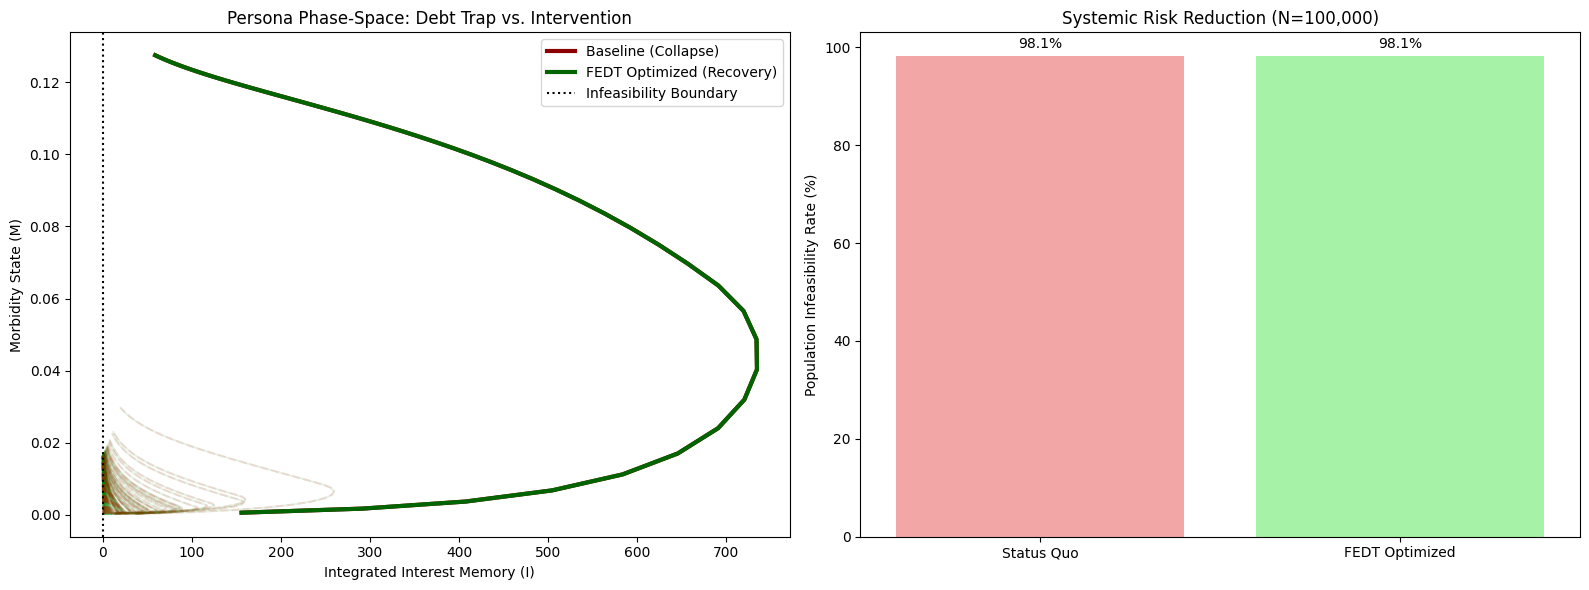

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data for Plotting
# We'll take the first 100 personas to show a 'spaghetti plot' of trajectories
N_samples = 100
t_axis = jnp.arange(T_MONTHS)

# Compute baseline and optimized histories
zero_U_plan = jnp.zeros_like(U_plan) # No intervention for baseline
baseline_hist = run_ensemble(X_initial, zero_U_plan, params)
optimized_hist = run_ensemble(X_initial, U_plan, params)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot A: Phase-Space (Interest Memory vs Morbidity) ---
for i in range(N_samples):
    # Baseline (Red/Dashed)
    ax1.plot(baseline_hist[i, :, 6], baseline_hist[i, :, 5], color='red', alpha=0.1, linestyle='--')
    # Optimized (Green/Solid)
    ax1.plot(optimized_hist[i, :, 6], optimized_hist[i, :, 5], color='green', alpha=0.1)

# Highlight one specific 'at-risk' persona for clarity
target_idx = jnp.argmax(X_initial[:, 0]) # The persona with the highest initial debt
ax1.plot(baseline_hist[target_idx, :, 6], baseline_hist[target_idx, :, 5],
         color='darkred', linewidth=3, label='Baseline (Collapse)')
ax1.plot(optimized_hist[target_idx, :, 6], optimized_hist[target_idx, :, 5],
         color='darkgreen', linewidth=3, label='FEDT Optimized (Recovery)')

ax1.axvline(x=I_CRIT_VAL, color='black', linestyle=':', label='Infeasibility Boundary')
ax1.set_xlabel("Integrated Interest Memory (I)")
ax1.set_ylabel("Morbidity State (M)")
ax1.set_title("Persona Phase-Space: Debt Trap vs. Intervention")
ax1.legend()

# --- Plot B: Systemic Failure Rates (The Banking Metric) ---
b_fail = float((baseline_hist[:, :, 6] > I_CRIT_VAL).any(axis=1).mean() * 100)
o_fail = float((optimized_hist[:, :, 6] > I_CRIT_VAL).any(axis=1).mean() * 100)

sns.barplot(x=['Status Quo', 'FEDT Optimized'], y=[b_fail, o_fail], hue=['Status Quo', 'FEDT Optimized'], palette=['#ff9999', '#99ff99'], legend=False, ax=ax2)
ax2.set_ylabel("Population Infeasibility Rate (%)")
ax2.set_title("Systemic Risk Reduction (N=100,000)")
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.tight_layout()
plt.show()